# Task 4 — Variational Autoencoder on MNIST

## Task 4.1 — Setup

In [ ]:
import os, json, math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__, '| device:', DEVICE)
if DEVICE.type == 'cuda':
    print('gpu  :', torch.cuda.get_device_name(0))

FIG_DIR, CKPT_DIR, RES_DIR = 'figures/task4', 'checkpoints/task4', 'results'
for d in (FIG_DIR, CKPT_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.25,
})

RESULTS = {}   # everything numeric ends up here and is dumped to JSON at the end

torch: 2.11.0+cu128 | device: cuda
gpu  : Tesla T4


## Task 4.2 — Data

In [ ]:
BATCH_SIZE = 128
tf = transforms.ToTensor()               # -> float tensor in [0, 1], shape (1, 28, 28)

train_ds = datasets.MNIST('./data', train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=tf)

nw  = 2 if DEVICE.type == 'cuda' else 0
pin = DEVICE.type == 'cuda'
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=nw, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=512,        shuffle=False, num_workers=nw, pin_memory=pin)

print(f'train: {len(train_ds)} images | test: {len(test_ds)} images')
xb, yb = next(iter(train_loader))
print('batch:', tuple(xb.shape), '| range: [%.2f, %.2f]' % (xb.min(), xb.max()))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]

train: 60000 images | test: 10000 images


batch: (128, 1, 28, 28) | range: [0.00, 1.00]


## Task 4.3 — Model and loss

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2, hidden=(512, 256), in_dim=784):
        super().__init__()
        self.latent_dim, self.in_dim = latent_dim, in_dim
        h1, h2 = hidden

        self.encoder = nn.Sequential(
            nn.Linear(in_dim, h1), nn.ReLU(inplace=True),
            nn.Linear(h1, h2),     nn.ReLU(inplace=True),
        )
        self.fc_mu     = nn.Linear(h2, latent_dim)
        self.fc_logvar = nn.Linear(h2, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, h2), nn.ReLU(inplace=True),
            nn.Linear(h2, h1),         nn.ReLU(inplace=True),
            nn.Linear(h1, in_dim),                    # logits, no sigmoid here
        )

    def encode(self, x):
        h = self.encoder(x.view(-1, self.in_dim))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z)                        # logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z


def vae_loss(logits, x, mu, logvar):
    # Reconstruction: -E_q[log p(x|z)], Bernoulli, summed over the 784 pixels
    x_flat = x.view(x.size(0), -1)
    recon = F.binary_cross_entropy_with_logits(logits, x_flat, reduction='none').sum(dim=1)
    # KL( N(mu, sigma^2) || N(0, I) ) = 0.5 * sum_j ( mu_j^2 + sigma_j^2 - log sigma_j^2 - 1 )
    kl = 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1.0).sum(dim=1)
    loss = recon + kl                                 # negative ELBO, per image
    return loss.mean(), recon.mean().detach(), kl.mean().detach()


_m = VAE(latent_dim=10)
print(_m)
_n = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'\ntrainable parameters (d=10): {_n:,}')
del _m

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU(inplace=True)
  )
  (fc_mu): Linear(in_features=256, out_features=10, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=10, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=784, bias=True)
  )
)

trainable parameters (d=10): 1,074,980


### Task 4.3.1 — KL sanity check

In [ ]:
with torch.no_grad():
    mu_t     = torch.randn(64, 10)
    logvar_t = torch.randn(64, 10) * 0.5
    ours = 0.5 * (mu_t.pow(2) + logvar_t.exp() - logvar_t - 1.0).sum(dim=1)
    q = torch.distributions.Normal(mu_t, torch.exp(0.5 * logvar_t))
    p = torch.distributions.Normal(torch.zeros_like(mu_t), torch.ones_like(mu_t))
    ref = torch.distributions.kl_divergence(q, p).sum(dim=1)
    print('max abs difference:', (ours - ref).abs().max().item())
    assert torch.allclose(ours, ref, atol=1e-5), 'KL mismatch'
    print('closed-form KL matches torch.distributions')

max abs difference: 9.5367431640625e-07
closed-form KL matches torch.distributions


## Task 4.4 — Training

In [ ]:
def evaluate(model, loader):
    model.eval()
    tot_loss = tot_recon = tot_kl = 0.0
    n = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE, non_blocking=True)
            logits, mu, logvar, _ = model(x)
            loss, recon, kl = vae_loss(logits, x, mu, logvar)
            bs = x.size(0)
            tot_loss  += loss.item()  * bs
            tot_recon += recon.item() * bs
            tot_kl    += kl.item()    * bs
            n += bs
    return tot_loss / n, tot_recon / n, tot_kl / n


def train_vae(latent_dim, epochs=20, lr=1e-3, verbose_every=5):
    torch.manual_seed(SEED)                     # same init scheme across dims
    model = VAE(latent_dim=latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {'train_loss': [], 'train_recon': [], 'train_kl': [],
            'test_loss': [],  'test_recon': [],  'test_kl': []}

    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        tot_loss = tot_recon = tot_kl = 0.0
        n = 0
        for x, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits, mu, logvar, _ = model(x)
            loss, recon, kl = vae_loss(logits, x, mu, logvar)
            loss.backward()
            opt.step()
            bs = x.size(0)
            tot_loss  += loss.item()  * bs
            tot_recon += recon.item() * bs
            tot_kl    += kl.item()    * bs
            n += bs

        hist['train_loss'].append(tot_loss / n)
        hist['train_recon'].append(tot_recon / n)
        hist['train_kl'].append(tot_kl / n)
        te_loss, te_recon, te_kl = evaluate(model, test_loader)
        hist['test_loss'].append(te_loss)
        hist['test_recon'].append(te_recon)
        hist['test_kl'].append(te_kl)

        if ep == 1 or ep % verbose_every == 0 or ep == epochs:
            print(f'  epoch {ep:>2}/{epochs} | train -ELBO {hist["train_loss"][-1]:7.2f} '
                  f'| test -ELBO {te_loss:7.2f} (recon {te_recon:6.2f}, KL {te_kl:5.2f})')

    hist['train_time_s'] = time.time() - t0
    hist['n_params'] = sum(p.numel() for p in model.parameters())
    return model, hist

In [ ]:
LATENT_DIMS = [2, 5, 10, 20]
EPOCHS = 20

models, histories = {}, {}
for d in LATENT_DIMS:
    print(f'\n=== latent_dim = {d} ===')
    m, h = train_vae(d, epochs=EPOCHS)
    models[d], histories[d] = m, h
    torch.save(m.state_dict(), f'{CKPT_DIR}/vae_d{d}.pt')
    print(f'  done in {h["train_time_s"]:.1f}s | params {h["n_params"]:,}')

RESULTS['config'] = {'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'lr': 1e-3,
                     'hidden': [512, 256], 'latent_dims': LATENT_DIMS,
                     'optimizer': 'Adam', 'seed': SEED, 'device': str(DEVICE)}
RESULTS['histories'] = {str(d): histories[d] for d in LATENT_DIMS}
RESULTS['final'] = {str(d): {'test_neg_elbo': histories[d]['test_loss'][-1],
                             'test_recon':    histories[d]['test_recon'][-1],
                             'test_kl':       histories[d]['test_kl'][-1],
                             'train_neg_elbo':histories[d]['train_loss'][-1],
                             'n_params':      histories[d]['n_params'],
                             'train_time_s':  histories[d]['train_time_s']}
                     for d in LATENT_DIMS}

print('\nFinal test negative ELBO (nats/image):')
for d in LATENT_DIMS:
    f = RESULTS['final'][str(d)]
    print(f'  d={d:>2}: {f["test_neg_elbo"]:7.2f}  = recon {f["test_recon"]:6.2f} + KL {f["test_kl"]:5.2f}')


=== latent_dim = 2 ===
  epoch  1/20 | train -ELBO  183.40 | test -ELBO  164.78 (recon 159.59, KL  5.18)
  epoch  5/20 | train -ELBO  149.43 | test -ELBO  148.86 (recon 142.64, KL  6.22)
  epoch 10/20 | train -ELBO  144.04 | test -ELBO  145.04 (recon 138.60, KL  6.43)
  epoch 15/20 | train -ELBO  141.49 | test -ELBO  142.79 (recon 136.25, KL  6.54)
  epoch 20/20 | train -ELBO  139.42 | test -ELBO  141.16 (recon 134.21, KL  6.95)
  done in 179.9s | params 1,068,820

=== latent_dim = 5 ===
  epoch  1/20 | train -ELBO  173.48 | test -ELBO  137.55 (recon 127.02, KL 10.53)
  epoch  5/20 | train -ELBO  123.33 | test -ELBO  122.73 (recon 111.59, KL 11.14)
  epoch 10/20 | train -ELBO  118.03 | test -ELBO  118.50 (recon 106.62, KL 11.88)
  epoch 15/20 | train -ELBO  115.21 | test -ELBO  116.57 (recon 104.46, KL 12.11)
  epoch 20/20 | train -ELBO  113.47 | test -ELBO  115.48 (recon 102.92, KL 12.56)
  done in 176.2s | params 1,071,130

=== latent_dim = 10 ===
  epoch  1/20 | train -ELBO  172.80

### Task 4.4.1 — ELBO curves

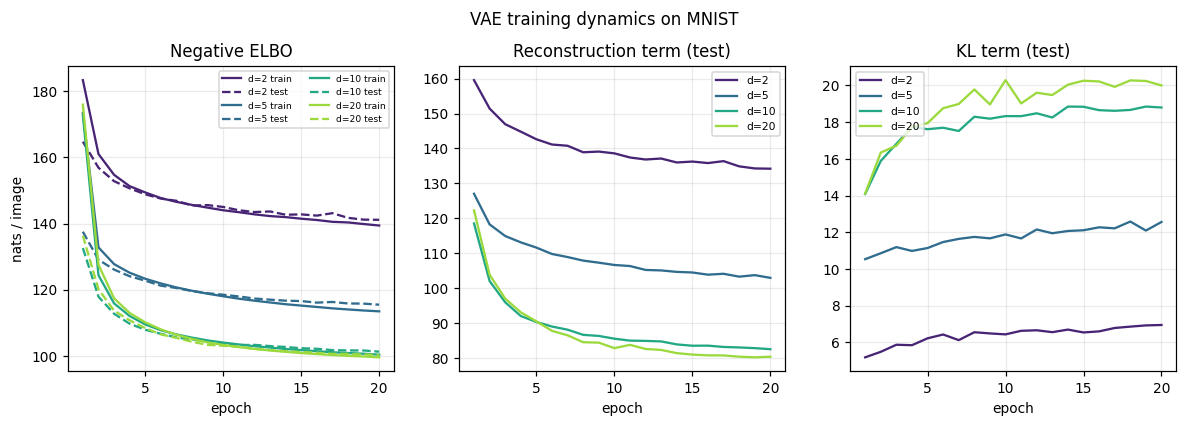

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
epochs_axis = np.arange(1, EPOCHS + 1)
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(LATENT_DIMS)))

for c, d in zip(colors, LATENT_DIMS):
    h = histories[d]
    axes[0].plot(epochs_axis, h['train_loss'], color=c, label=f'd={d} train')
    axes[0].plot(epochs_axis, h['test_loss'],  color=c, ls='--', label=f'd={d} test')
    axes[1].plot(epochs_axis, h['test_recon'], color=c, label=f'd={d}')
    axes[2].plot(epochs_axis, h['test_kl'],    color=c, label=f'd={d}')

axes[0].set_title('Negative ELBO'); axes[0].set_ylabel('nats / image')
axes[1].set_title('Reconstruction term (test)')
axes[2].set_title('KL term (test)')
for ax in axes:
    ax.set_xlabel('epoch')
axes[0].legend(fontsize=6, ncol=2)
axes[1].legend(fontsize=7); axes[2].legend(fontsize=7)
fig.suptitle('VAE training dynamics on MNIST', y=1.02)
fig.savefig(f'{FIG_DIR}/elbo_curves.png')
plt.show()

## Task 4.5 — Latent space visualization

In [ ]:
@torch.no_grad()
def encode_dataset(model, loader):
    model.eval()
    mus, logvars, labels = [], [], []
    for x, y in loader:
        mu, logvar = model.encode(x.to(DEVICE, non_blocking=True))
        mus.append(mu.cpu()); logvars.append(logvar.cpu()); labels.append(y)
    return torch.cat(mus).numpy(), torch.cat(logvars).numpy(), torch.cat(labels).numpy()

latents = {d: encode_dataset(models[d], test_loader) for d in LATENT_DIMS}
for d in LATENT_DIMS:
    print(f'd={d}: mu shape {latents[d][0].shape}')

d=2: mu shape (10000, 2)
d=5: mu shape (10000, 5)
d=10: mu shape (10000, 10)
d=20: mu shape (10000, 20)


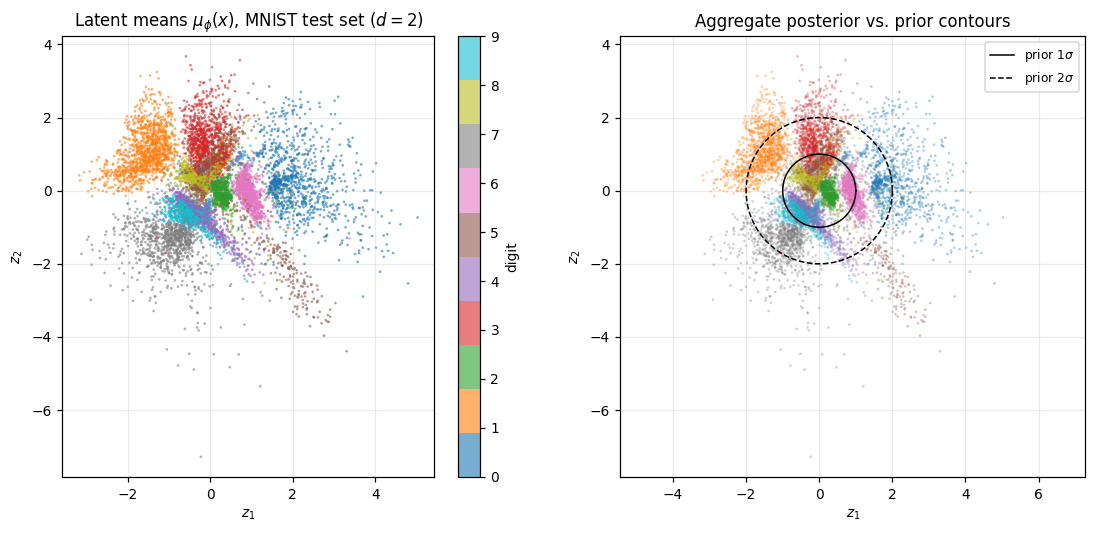

aggregate posterior: mean = [0.002 0.056], std = [1.08  1.014]


In [ ]:
mu2, logvar2, lab2 = latents[2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

sc = axes[0].scatter(mu2[:, 0], mu2[:, 1], c=lab2, cmap='tab10', s=3, alpha=0.6, linewidths=0)
axes[0].set_title(r'Latent means $\mu_\phi(x)$, MNIST test set ($d=2$)')
axes[0].set_xlabel(r'$z_1$'); axes[0].set_ylabel(r'$z_2$')
cb = fig.colorbar(sc, ax=axes[0], ticks=range(10)); cb.set_label('digit')

# overlay the prior for reference: the aggregate posterior should roughly match N(0, I)
theta = np.linspace(0, 2 * np.pi, 200)
for r, ls in [(1, '-'), (2, '--')]:
    axes[1].plot(r * np.cos(theta), r * np.sin(theta), 'k', ls=ls, lw=1,
                 label=f'prior {r}$\\sigma$')
axes[1].scatter(mu2[:, 0], mu2[:, 1], c=lab2, cmap='tab10', s=3, alpha=0.35, linewidths=0)
axes[1].set_title('Aggregate posterior vs. prior contours')
axes[1].set_xlabel(r'$z_1$'); axes[1].set_ylabel(r'$z_2$'); axes[1].legend(fontsize=8)
axes[1].set_aspect('equal', adjustable='datalim')

fig.savefig(f'{FIG_DIR}/latent_space_d2.png')
plt.show()

print('aggregate posterior: mean = %s, std = %s' %
      (np.round(mu2.mean(0), 3), np.round(mu2.std(0), 3)))

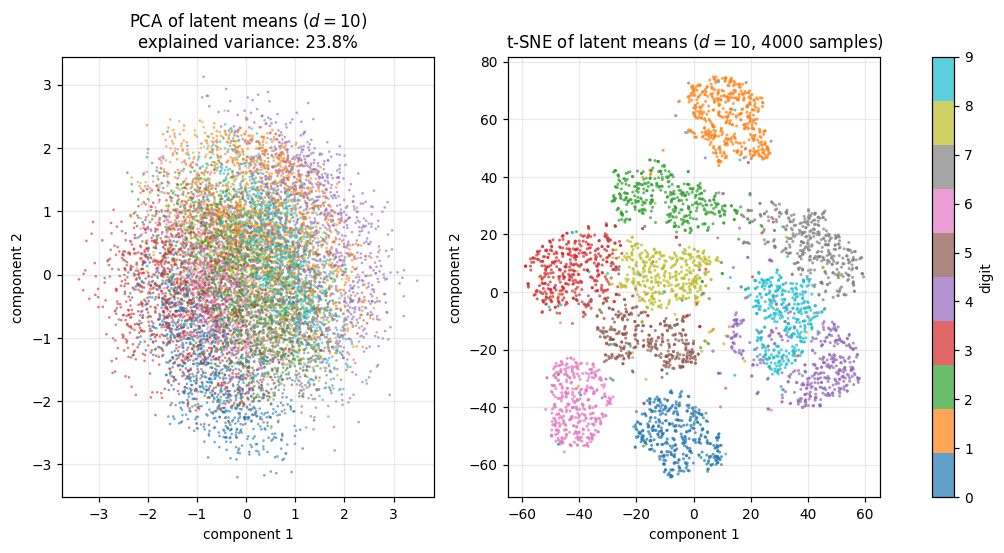

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

D_HIGH = 10
mu_h, _, lab_h = latents[D_HIGH]

pca = PCA(n_components=2).fit(mu_h)
proj_pca = pca.transform(mu_h)

sub = np.random.RandomState(SEED).choice(len(mu_h), size=4000, replace=False)   # t-SNE is O(n^2)-ish
proj_tsne = TSNE(n_components=2, perplexity=30, init='pca',
                 learning_rate='auto', random_state=SEED).fit_transform(mu_h[sub])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
s0 = axes[0].scatter(proj_pca[:, 0], proj_pca[:, 1], c=lab_h, cmap='tab10', s=3, alpha=0.6, linewidths=0)
axes[0].set_title(f'PCA of latent means ($d={D_HIGH}$)\n'
                  f'explained variance: {pca.explained_variance_ratio_.sum():.1%}')
s1 = axes[1].scatter(proj_tsne[:, 0], proj_tsne[:, 1], c=lab_h[sub], cmap='tab10', s=4, alpha=0.7, linewidths=0)
axes[1].set_title(f't-SNE of latent means ($d={D_HIGH}$, {len(sub)} samples)')
for ax in axes:
    ax.set_xlabel('component 1'); ax.set_ylabel('component 2')
cb = fig.colorbar(s1, ax=axes, ticks=range(10)); cb.set_label('digit')
fig.savefig(f'{FIG_DIR}/latent_space_d10_pca_tsne.png')
plt.show()

RESULTS['pca_explained_variance_d10'] = pca.explained_variance_ratio_.tolist()

### Task 4.5.1 — Cluster separability

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

knn_scores, sil_scores = {}, {}
for d in LATENT_DIMS:
    mu_d, _, lab_d = latents[d]
    Xtr, Xte, ytr, yte = train_test_split(mu_d, lab_d, test_size=0.3, random_state=SEED, stratify=lab_d)
    knn = KNeighborsClassifier(n_neighbors=10).fit(Xtr, ytr)
    knn_scores[d] = float(knn.score(Xte, yte))
    idx = np.random.RandomState(SEED).choice(len(mu_d), 3000, replace=False)
    sil_scores[d] = float(silhouette_score(mu_d[idx], lab_d[idx]))
    print(f'd={d:>2}: 10-NN accuracy on latent means = {knn_scores[d]:.4f} | silhouette = {sil_scores[d]:+.4f}')

RESULTS['knn_accuracy'] = {str(k): v for k, v in knn_scores.items()}
RESULTS['silhouette']  = {str(k): v for k, v in sil_scores.items()}

d= 2: 10-NN accuracy on latent means = 0.8090 | silhouette = +0.1207
d= 5: 10-NN accuracy on latent means = 0.9347 | silhouette = +0.1611
d=10: 10-NN accuracy on latent means = 0.9513 | silhouette = +0.0956
d=20: 10-NN accuracy on latent means = 0.9530 | silhouette = +0.0822


### Task 4.5.2 — Decoder manifold (d = 2)

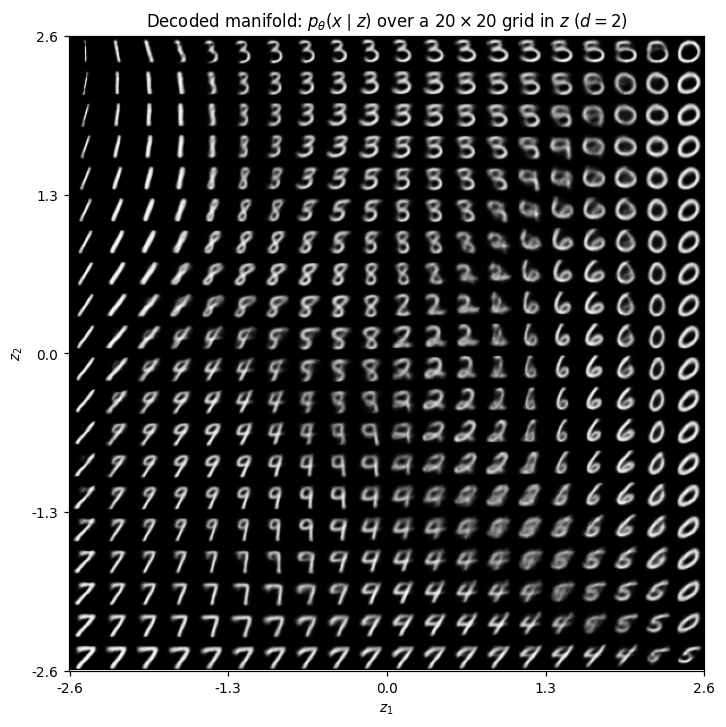

In [ ]:
from scipy.stats import norm

@torch.no_grad()
def decode_grid(model, n=20, span=0.995):
    model.eval()
    lin = norm.ppf(np.linspace(1 - span, span, n))
    zs = np.array([[xi, yi] for yi in lin[::-1] for xi in lin], dtype=np.float32)
    probs = torch.sigmoid(model.decode(torch.from_numpy(zs).to(DEVICE))).cpu()
    return probs.view(-1, 1, 28, 28), lin

grid_imgs, lin = decode_grid(models[2], n=20)
canvas = make_grid(grid_imgs, nrow=20, padding=0).permute(1, 2, 0).numpy()

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(canvas, cmap='gray')
ax.set_title(r'Decoded manifold: $p_\theta(x \mid z)$ over a $20\times20$ grid in $z$ ($d=2$)')
ax.set_xticks(np.linspace(0, canvas.shape[1], 5))
ax.set_xticklabels(np.round(np.linspace(lin[0], lin[-1], 5), 1))
ax.set_yticks(np.linspace(0, canvas.shape[0], 5))
ax.set_yticklabels(np.round(np.linspace(lin[-1], lin[0], 5), 1))
ax.set_xlabel(r'$z_1$'); ax.set_ylabel(r'$z_2$'); ax.grid(False)
fig.savefig(f'{FIG_DIR}/latent_manifold_d2.png')
plt.show()

## Task 4.6 — Reconstruction quality

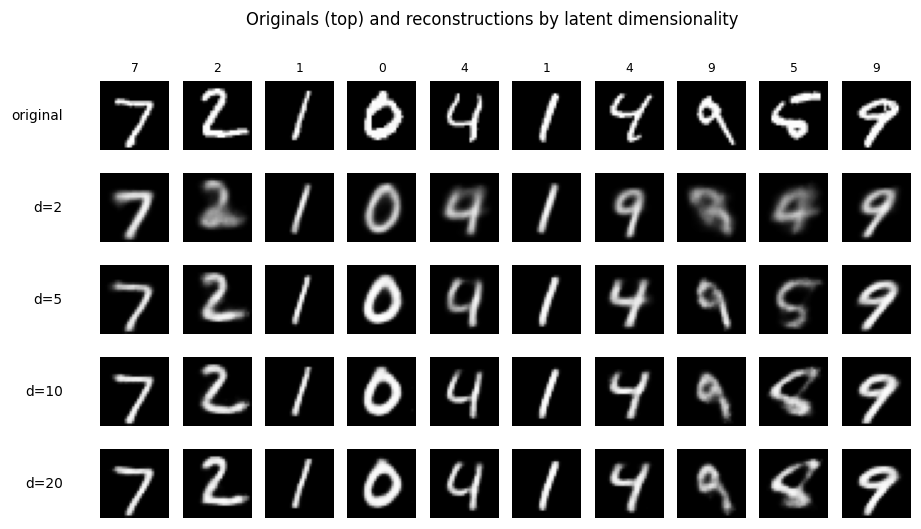

In [ ]:
N_SHOW = 10
fixed_x = torch.stack([test_ds[i][0] for i in range(N_SHOW)])
fixed_y = [int(test_ds[i][1]) for i in range(N_SHOW)]

@torch.no_grad()
def reconstruct(model, x, sample=False):
    model.eval()
    mu, logvar = model.encode(x.to(DEVICE))
    z = model.reparameterize(mu, logvar) if sample else mu
    return torch.sigmoid(model.decode(z)).view(-1, 1, 28, 28).cpu()

rows = [('original', fixed_x)] + [(f'd={d}', reconstruct(models[d], fixed_x)) for d in LATENT_DIMS]

fig, axes = plt.subplots(len(rows), N_SHOW, figsize=(N_SHOW * 0.95, len(rows) * 1.05))
for r, (name, imgs) in enumerate(rows):
    for c in range(N_SHOW):
        axes[r, c].imshow(imgs[c, 0], cmap='gray', vmin=0, vmax=1)
        axes[r, c].axis('off')
        if r == 0:
            axes[r, c].set_title(str(fixed_y[c]), fontsize=8)
    axes[r, 0].text(-0.55, 0.5, name, transform=axes[r, 0].transAxes,
                    ha='right', va='center', fontsize=9)
fig.suptitle('Originals (top) and reconstructions by latent dimensionality', y=0.995)
fig.savefig(f'{FIG_DIR}/reconstructions.png')
plt.show()

### Task 4.6.1 — Per-digit reconstruction error

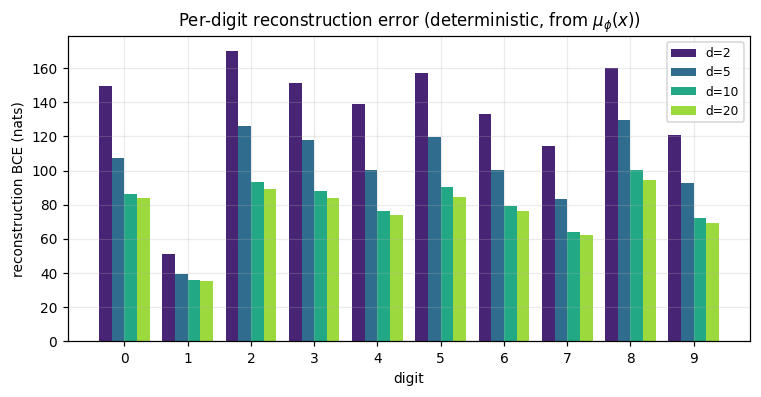

d=10: easiest digit = 1 (35.7 nats), hardest = 8 (100.2 nats)


In [ ]:
@torch.no_grad()
def per_digit_errors(model, loader):
    model.eval()
    err = np.zeros(10); cnt = np.zeros(10)
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        mu, logvar = model.encode(x)
        logits = model.decode(mu)
        bce = F.binary_cross_entropy_with_logits(
            logits, x.view(x.size(0), -1), reduction='none').sum(1).cpu().numpy()
        for c in range(10):
            m = (y.numpy() == c)
            err[c] += bce[m].sum(); cnt[c] += m.sum()
    return err / cnt

pd_err = {d: per_digit_errors(models[d], test_loader) for d in LATENT_DIMS}

fig, ax = plt.subplots(figsize=(8, 3.6))
w = 0.8 / len(LATENT_DIMS)
for i, (c, d) in enumerate(zip(colors, LATENT_DIMS)):
    ax.bar(np.arange(10) + i * w - 0.4 + w / 2, pd_err[d], width=w, color=c, label=f'd={d}')
ax.set_xticks(range(10)); ax.set_xlabel('digit'); ax.set_ylabel('reconstruction BCE (nats)')
ax.set_title('Per-digit reconstruction error (deterministic, from $\\mu_\\phi(x)$)')
ax.legend(fontsize=8)
fig.savefig(f'{FIG_DIR}/per_digit_error.png')
plt.show()

RESULTS['per_digit_recon_bce'] = {str(d): pd_err[d].tolist() for d in LATENT_DIMS}
best_d, worst_d = int(np.argmin(pd_err[10])), int(np.argmax(pd_err[10]))
print(f'd=10: easiest digit = {best_d} ({pd_err[10][best_d]:.1f} nats), '
      f'hardest = {worst_d} ({pd_err[10][worst_d]:.1f} nats)')

## Task 4.7 — Generation from the prior

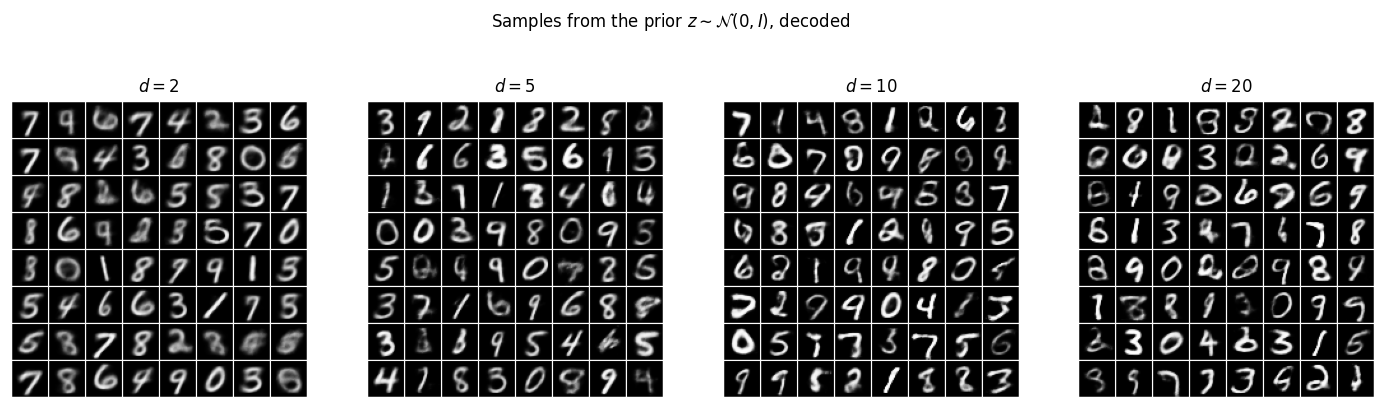

In [ ]:
@torch.no_grad()
def sample_prior(model, n=64, seed=SEED):
    model.eval()
    g = torch.Generator(device='cpu').manual_seed(seed)
    z = torch.randn(n, model.latent_dim, generator=g).to(DEVICE)
    return torch.sigmoid(model.decode(z)).view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(1, len(LATENT_DIMS), figsize=(4 * len(LATENT_DIMS), 4.3))
for ax, d in zip(axes, LATENT_DIMS):
    grid = make_grid(sample_prior(models[d], 64), nrow=8, padding=1, pad_value=1.0)
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(f'$d={d}$'); ax.axis('off')
fig.suptitle(r'Samples from the prior $z \sim \mathcal{N}(0, I)$, decoded', y=1.0)
fig.savefig(f'{FIG_DIR}/prior_samples.png')
plt.show()

### Task 4.7.1 — Latent interpolation

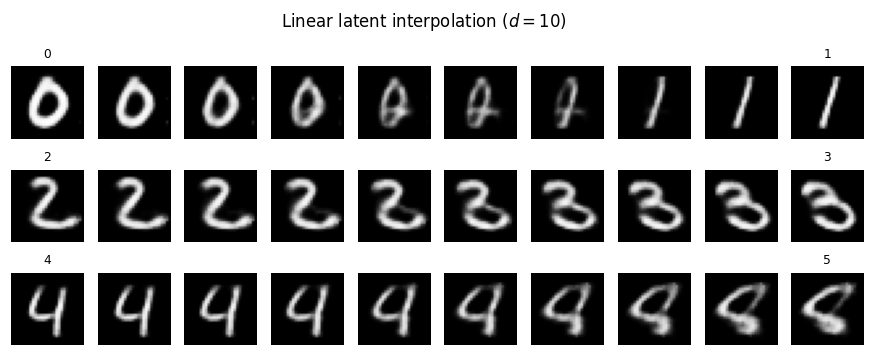

In [ ]:
@torch.no_grad()
def interpolate(model, x1, x2, steps=10):
    model.eval()
    mu, _ = model.encode(torch.stack([x1, x2]).to(DEVICE))
    alphas = torch.linspace(0, 1, steps, device=DEVICE).unsqueeze(1)
    z = (1 - alphas) * mu[0:1] + alphas * mu[1:2]
    return torch.sigmoid(model.decode(z)).view(-1, 1, 28, 28).cpu()

pairs = [(3, 2), (1, 18), (4, 8)]   # arbitrary test indices with different labels
fig, axes = plt.subplots(len(pairs), 10, figsize=(10, len(pairs) * 1.15))
for r, (i, j) in enumerate(pairs):
    seq = interpolate(models[D_HIGH], test_ds[i][0], test_ds[j][0], steps=10)
    for c in range(10):
        axes[r, c].imshow(seq[c, 0], cmap='gray', vmin=0, vmax=1); axes[r, c].axis('off')
    axes[r, 0].set_title(f'{int(test_ds[i][1])}', fontsize=8)
    axes[r, 9].set_title(f'{int(test_ds[j][1])}', fontsize=8)
fig.suptitle(f'Linear latent interpolation ($d={D_HIGH}$)', y=1.01)
fig.savefig(f'{FIG_DIR}/latent_interpolation.png')
plt.show()

## Task 4.8 — Comparison with Doersch's implementation

In [ ]:
print(f'{"d":>3} | {"-ELBO":>7} | {"recon":>7} | {"KL":>6} | {"KL/dim":>7} | {"10-NN":>6} | {"params":>9}')
print('-' * 62)
for d in LATENT_DIMS:
    f = RESULTS['final'][str(d)]
    print(f'{d:>3} | {f["test_neg_elbo"]:7.2f} | {f["test_recon"]:7.2f} | {f["test_kl"]:6.2f} | '
          f'{f["test_kl"]/d:7.2f} | {knn_scores[d]:6.3f} | {f["n_params"]:9,}')

elbos = [RESULTS['final'][str(d)]['test_neg_elbo'] for d in LATENT_DIMS]
print(f'\nSpread in test -ELBO across d={LATENT_DIMS[0]}..{LATENT_DIMS[-1]}: {max(elbos) - min(elbos):.2f} nats')
print(f'Spread excluding d=2 (i.e. within Doersch\'s "broad range"): {max(elbos[1:]) - min(elbos[1:]):.2f} nats')

  d |   -ELBO |   recon |     KL |  KL/dim |  10-NN |    params
--------------------------------------------------------------
  2 |  141.16 |  134.21 |   6.95 |    3.47 |  0.809 | 1,068,820
  5 |  115.48 |  102.92 |  12.56 |    2.51 |  0.935 | 1,071,130
 10 |  101.28 |   82.48 |  18.80 |    1.88 |  0.951 | 1,074,980
 20 |  100.32 |   80.32 |  20.00 |    1.00 |  0.953 | 1,082,680

Spread in test -ELBO across d=2..20: 40.83 nats
Spread excluding d=2 (i.e. within Doersch's "broad range"): 15.16 nats


## Task 4.9 — Export results and LaTeX tables

In [ ]:
with open(f'{RES_DIR}/task4_results.json', 'w') as f:
    json.dump(RESULTS, f, indent=2)
print(f'wrote {RES_DIR}/task4_results.json')

lines = []
lines.append(r'% ---- Table: effect of latent dimensionality -------------------------------')
lines.append(r'\begin{table}[t]')
lines.append(r'\centering')
lines.append(r'\caption{Effect of latent dimensionality on MNIST VAE performance. All quantities are per image on '
             r'the 10{,}000-image test set after ' + str(EPOCHS) + r' epochs. The $k$-NN accuracy ($k=10$) is a '
             r'linear-probe-style measure of how much class structure survives the bottleneck; the VAE is trained '
             r'without labels.}')
lines.append(r'\label{tab:vae-latent-dim}')
lines.append(r'\begin{tabular}{rrrrrrr}')
lines.append(r'\toprule')
lines.append(r'$d$ & $-$ELBO & Recon. & KL & KL$/d$ & 10-NN acc. & Params \\')
lines.append(r'\midrule')
for d in LATENT_DIMS:
    f_ = RESULTS['final'][str(d)]
    params_tex = f'{f_["n_params"]:,}'.replace(',', r'{,}')     # LaTeX-safe thousands separator
    lines.append(f'{d} & {f_["test_neg_elbo"]:.2f} & {f_["test_recon"]:.2f} & {f_["test_kl"]:.2f} & '
                 f'{f_["test_kl"]/d:.2f} & {knn_scores[d]:.3f} & {params_tex} ' + r'\\')
lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\end{table}')
lines.append('')

lines.append(r'% ---- Table: per-digit reconstruction error -------------------------------')
lines.append(r'\begin{table}[t]')
lines.append(r'\centering')
lines.append(r'\caption{Per-digit reconstruction cost (Bernoulli negative log-likelihood, nats per image), '
             r'decoded deterministically from $\mu_\phi(x)$.}')
lines.append(r'\label{tab:vae-per-digit}')
lines.append(r'\begin{tabular}{r' + 'r' * 10 + r'}')
lines.append(r'\toprule')
lines.append(r'$d$ & ' + ' & '.join(str(c) for c in range(10)) + r' \\')
lines.append(r'\midrule')
for d in LATENT_DIMS:
    lines.append(f'{d} & ' + ' & '.join(f'{v:.1f}' for v in pd_err[d]) + r' \\')
lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\end{table}')

tex = '\n'.join(lines)
with open(f'{RES_DIR}/task4_tables.tex', 'w') as f:
    f.write(tex)
print(f'wrote {RES_DIR}/task4_tables.tex\n')
print(tex)

wrote results/task4_results.json
wrote results/task4_tables.tex

% ---- Table: effect of latent dimensionality -------------------------------
\begin{table}[t]
\centering
\caption{Effect of latent dimensionality on MNIST VAE performance. All quantities are per image on the 10{,}000-image test set after 20 epochs. The $k$-NN accuracy ($k=10$) is a linear-probe-style measure of how much class structure survives the bottleneck; the VAE is trained without labels.}
\label{tab:vae-latent-dim}
\begin{tabular}{rrrrrrr}
\toprule
$d$ & $-$ELBO & Recon. & KL & KL$/d$ & 10-NN acc. & Params \\
\midrule
2 & 141.16 & 134.21 & 6.95 & 3.47 & 0.809 & 1{,}068{,}820 \\
5 & 115.48 & 102.92 & 12.56 & 2.51 & 0.935 & 1{,}071{,}130 \\
10 & 101.28 & 82.48 & 18.80 & 1.88 & 0.951 & 1{,}074{,}980 \\
20 & 100.32 & 80.32 & 20.00 & 1.00 & 0.953 & 1{,}082{,}680 \\
\bottomrule
\end{tabular}
\end{table}

% ---- Table: per-digit reconstruction error -------------------------------
\begin{table}[t]
\centering
\caption{Per

In [ ]:
# Bundle figures + results for download. Deliberately excludes ./data (the MNIST download)
# and ./checkpoints (weights, ~10 MB) - add them below if you want them in the repo.
import shutil, glob, zipfile

BUNDLE = 'task4_bundle.zip'
with zipfile.ZipFile(BUNDLE, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(glob.glob(f'{FIG_DIR}/*.png')) + sorted(glob.glob(f'{RES_DIR}/task4_*')):
        zf.write(p)

print('figures produced:')
for p in sorted(glob.glob(f'{FIG_DIR}/*.png')):
    print('  ', p, f'({os.path.getsize(p)/1024:.0f} KB)')
print(f'\nbundled -> {BUNDLE} ({os.path.getsize(BUNDLE)/1024:.0f} KB)')

try:
    from google.colab import files
    files.download(BUNDLE)
except ImportError:
    print('Not running in Colab - files are in ./figures, ./results, ./checkpoints')

figures produced:
   figures/task4/elbo_curves.png (187 KB)
   figures/task4/latent_interpolation.png (45 KB)
   figures/task4/latent_manifold_d2.png (721 KB)
   figures/task4/latent_space_d10_pca_tsne.png (793 KB)
   figures/task4/latent_space_d2.png (491 KB)
   figures/task4/per_digit_error.png (46 KB)
   figures/task4/prior_samples.png (573 KB)
   figures/task4/reconstructions.png (77 KB)

bundled -> task4_bundle.zip (2833 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>